In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
df = pd.read_excel(r"C:\Users\ivans\Desktop\All\MSC\Data_Processsing\assignement\air_quality_analysis\data\processed\feature_engineered_air_quality_data.xlsx")

In [9]:
target_column = "air_quality_level"

In [5]:
class_order = [
    "Good",
    "Moderate",
    "Unhealthy for Sensitive Groups",
    "Unhealthy",
    "Very Unhealthy"
]

class_counts = (
    df[target_column]
    .value_counts()
    .reindex(class_order, fill_value=0)
)

class_percentages = (
    class_counts
    .div(class_counts.sum())
    .mul(100)
)

ideal_percentage = 100 / len(class_order)
ideal_count = class_counts.sum() / len(class_order)

class_distribution = pd.DataFrame({
    "Air Quality Level": class_order,
    "Count": class_counts.values,
    "Percentage": class_percentages.values,
    "Difference from Ideal Percentage":
        class_percentages.values - ideal_percentage
})

print("Class Distribution:")
print(class_distribution.round(2))

print("\nIdeal count per class for a perfectly balanced dataset:")
print(f"{ideal_count:,.2f}")

print("\nIdeal percentage per class:")
print(f"{ideal_percentage:.2f}%")

Class Distribution:
                Air Quality Level  Count  Percentage  \
0                            Good   7678       35.34   
1                        Moderate   9200       42.34   
2  Unhealthy for Sensitive Groups   1792        8.25   
3                       Unhealthy   2007        9.24   
4                  Very Unhealthy   1052        4.84   

   Difference from Ideal Percentage  
0                             15.34  
1                             22.34  
2                            -11.75  
3                            -10.76  
4                            -15.16  

Ideal count per class for a perfectly balanced dataset:
4,345.80

Ideal percentage per class:
20.00%


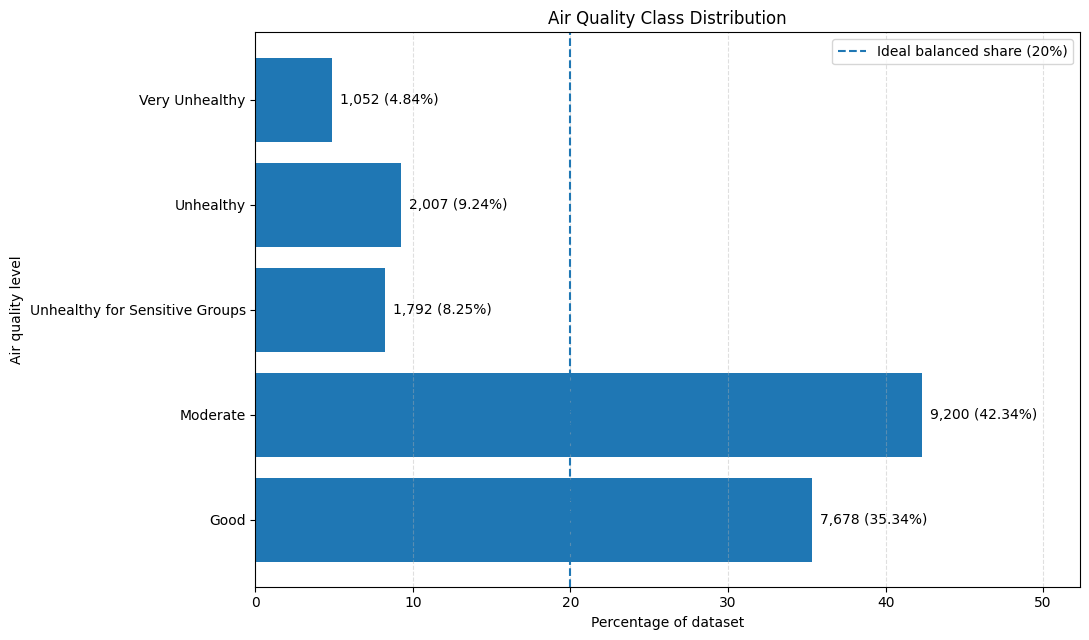

In [6]:
plt.figure(figsize=(11, 6.5))

bars = plt.barh(
    class_distribution["Air Quality Level"],
    class_distribution["Percentage"]
)

plt.axvline(
    ideal_percentage,
    linestyle="--",
    linewidth=1.5,
    label=f"Ideal balanced share ({ideal_percentage:.0f}%)"
)

for bar, count, percentage in zip(
    bars,
    class_distribution["Count"],
    class_distribution["Percentage"]
):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({percentage:.2f}%)",
        va="center"
    )

plt.title("Air Quality Class Distribution")
plt.xlabel("Percentage of dataset")
plt.ylabel("Air quality level")
plt.xlim(
    0,
    class_distribution["Percentage"].max() + 10
)
plt.legend()
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)
plt.tight_layout()
plt.show()

In [7]:
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count

print("Majority class:", majority_class)
print("Majority class count:", majority_count)

print("\nMinority class:", minority_class)
print("Minority class count:", minority_count)

print("\nMajority-to-minority imbalance ratio:")
print(f"{imbalance_ratio:.2f}:1")

Majority class: Moderate
Majority class count: 9200

Minority class: Very Unhealthy
Minority class count: 1052

Majority-to-minority imbalance ratio:
8.75:1


In [8]:
number_of_samples = len(df)
number_of_classes = len(class_counts)

balanced_class_weights = (
    number_of_samples
    / (number_of_classes * class_counts)
)

class_weight_table = pd.DataFrame({
    "Air Quality Level": class_order,
    "Count": class_counts.values,
    "Percentage": class_percentages.values,
    "Balanced Class Weight":
        balanced_class_weights.values
})

print(class_weight_table.round(3))

                Air Quality Level  Count  Percentage  Balanced Class Weight
0                            Good   7678      35.335                  0.566
1                        Moderate   9200      42.340                  0.472
2  Unhealthy for Sensitive Groups   1792       8.247                  2.425
3                       Unhealthy   2007       9.237                  2.165
4                  Very Unhealthy   1052       4.841                  4.131
